## Embeddings + Clustering

# Topic Modeling, Categorisations & Visualising over Time

## Setup, Load data, Create df

In [ ]:
# packages & libraries

import os
import pandas as pd
from collections import Counter
import re

from tqdm import tqdm
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Step 1: Load all CSV files
def load_data(folder_path, file_type='barriers'):
    print(f"\n📂 Loading {file_type} data...")
    all_data = []
    files = [f for f in os.listdir(folder_path) if f.startswith(file_type) and f.endswith('.csv')]

    for filename in tqdm(files, desc="Reading CSV files"):
        df = pd.read_csv(os.path.join(folder_path, filename))
        # Filter out NO_BARRIERS_FOUND / NO_MOTIVATORS_FOUND
        df = df[~df[file_type].str.contains('NO_', na=False)]
        all_data.append(df)

    result = pd.concat(all_data, ignore_index=True)
    print(f"✅ Loaded {len(result)} {file_type} entries")
    return result

barriers_df = load_data('decarbonisation_tables', 'barriers')
motivators_df = load_data('decarbonisation_tables', 'motivators')







barriers_df.to_csv("barriers_clustered.csv", index=False)
motivators_df.to_csv("motivators_clustered.csv", index=False)


📂 Loading barriers data...


Reading CSV files: 100%|██████████| 15/15 [00:00<00:00, 353.81it/s]


✅ Loaded 20 barriers entries

📂 Loading motivators data...


Reading CSV files: 100%|██████████| 15/15 [00:00<00:00, 1639.00it/s]

✅ Loaded 19 motivators entries


In [ ]:
# Step 2+3: Embeddings + Clustering

#!pip install sentence-transformers
import torch
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans


# Disable tokenizers warning
os.environ["TOKENIZERS_PARALLELISM"] = "false"


print("\n🤖 Loading sentence transformer model...")
# Use smaller, faster model or GPU if available
model = SentenceTransformer('all-MiniLM-L6-v2') # max token: 256-384


# check if gpu available
if torch.cuda.is_available():
    model = model.to('cuda')
    print("✅ Using GPU for encoding")
else:
    print("⚠️  Using CPU for encoding (slower)")


def cluster_and_categorize(df, text_column, n_clusters=8):
    print(f"\n🔄 Processing {len(df)} texts...")

    # Get embeddings with progress bar and batch processing
    texts = df[text_column].tolist()

    print("🧮 Generating embeddings...")
    embeddings = model.encode(
        texts,
        batch_size=32,  # Process in batches for efficiency
        show_progress_bar=True,
        convert_to_numpy=True
    )

    # Cluster
    print(f"📊 Clustering into {n_clusters} categories...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

    # Add progress for clustering (it's fast but nice to see)
    with tqdm(total=1, desc="K-means clustering") as pbar:
        clusters = kmeans.fit_predict(embeddings)
        pbar.update(1)

    df['cluster'] = clusters

    # Optional: Name clusters based on representative examples
    cluster_names = {}
    for i in range(n_clusters):
        cluster_texts = df[df['cluster'] == i][text_column].head(3)
        print(f"\nCluster {i} examples:")
        for text in cluster_texts:
            print(f"  - {text[:100]}...")

        # You can manually assign names or use LLM to generate them
        name = input(f"Name for cluster {i}: ") or f"Category_{i}"
        cluster_names[i] = name

    df['category'] = df['cluster'].map(cluster_names)
    return df

barriers_df = cluster_and_categorize(barriers_df, 'barriers', n_clusters=8)

barriers_df = cluster_and_categorize(barriers_df, 'barriers', n_clusters=8)

barriers_df = cluster_and_categorize(barriers_df, 'barriers', n_clusters=8)

barriers_df = cluster_and_categorize(barriers_df, 'barriers', n_clusters=8)

barriers_df = cluster_and_categorize(barriers_df, 'barriers', n_clusters=8)

barriers_df = cluster_and_categorize(barriers_df, 'barriers', n_clusters=8)
motivators_df = cluster_and_categorize(motivators_df, 'motivators', n_clusters=6)


🤖 Loading sentence transformer model...
⚠️  Using CPU for encoding (slower)

🔄 Processing 20 texts...
🧮 Generating embeddings...


Batches: 100%|██████████| 1/1 [00:00<00:00,  1.38it/s]


📊 Clustering into 8 categories...


K-means clustering: 100%|██████████| 1/1 [00:00<00:00,  8.89it/s]


Cluster 0 examples:
  - Higher investment costs for potential projects.
Higher operating costs for potential projects.
No te...
  - Industrial scaling up
Technologies by themselves are not sufficient to achieve carbon neutrality...


...

Batches: 100%|██████████| 1/1 [00:00<00:00,  1.06it/s]


📊 Clustering into 6 categories...


K-means clustering: 100%|██████████| 1/1 [00:00<00:00, 14.46it/s]


Cluster 0 examples:
  - Generating value in its business
Enabling the achievement of the transition plan
Cost-efficient deca...



Cluster 1 examples:
  - Environmental Sustainability Indicators
Goal Decarbonisation
Science-Based Targets initiative (SBTi)...
  - Be a responsible energy user
Help create a lower carbon future
Respond to geo-political realities dr...
  - Expression of empathy and concern regarding climate change
Knowing the risk of carbon and carbon pol...

Cluster 2 examples:
  - High climate ambition
Science-based target
Robust strategy
Measurable targets
Concrete actions
Suppo...
  - Investing in water treatment and recovery plants.
Setting targets aimed at improving carbon intensit...
  - Carbon Neutrality
Reduce carbon emissions by 8% by 2025
Achieve a 30% reduction by 2035
Reach carbon...

Cluster 3 examples:
  - Rate new recruitments
Billet energy intensity
Research projects proposed
The value of partnership...

Cluster 4 examples:
  - Reputation
Technology
Sustainable lifestyles
Responsible resource use
High-performing organisation
S...

Cluster 5 examples:
  - Facilitate the development and

## Aggregating

In [13]:
# Step 4: Aggregate by year and category
def aggregate_by_year(df, category_col='category'):
    yearly_counts = df.groupby(['year', category_col]).size().reset_index(name='count')
    return yearly_counts.pivot(index='year', columns=category_col, values='count').fillna(0)

barriers_yearly = aggregate_by_year(barriers_df, 'category')
motivators_yearly = aggregate_by_year(motivators_df, 'category')

## Charts

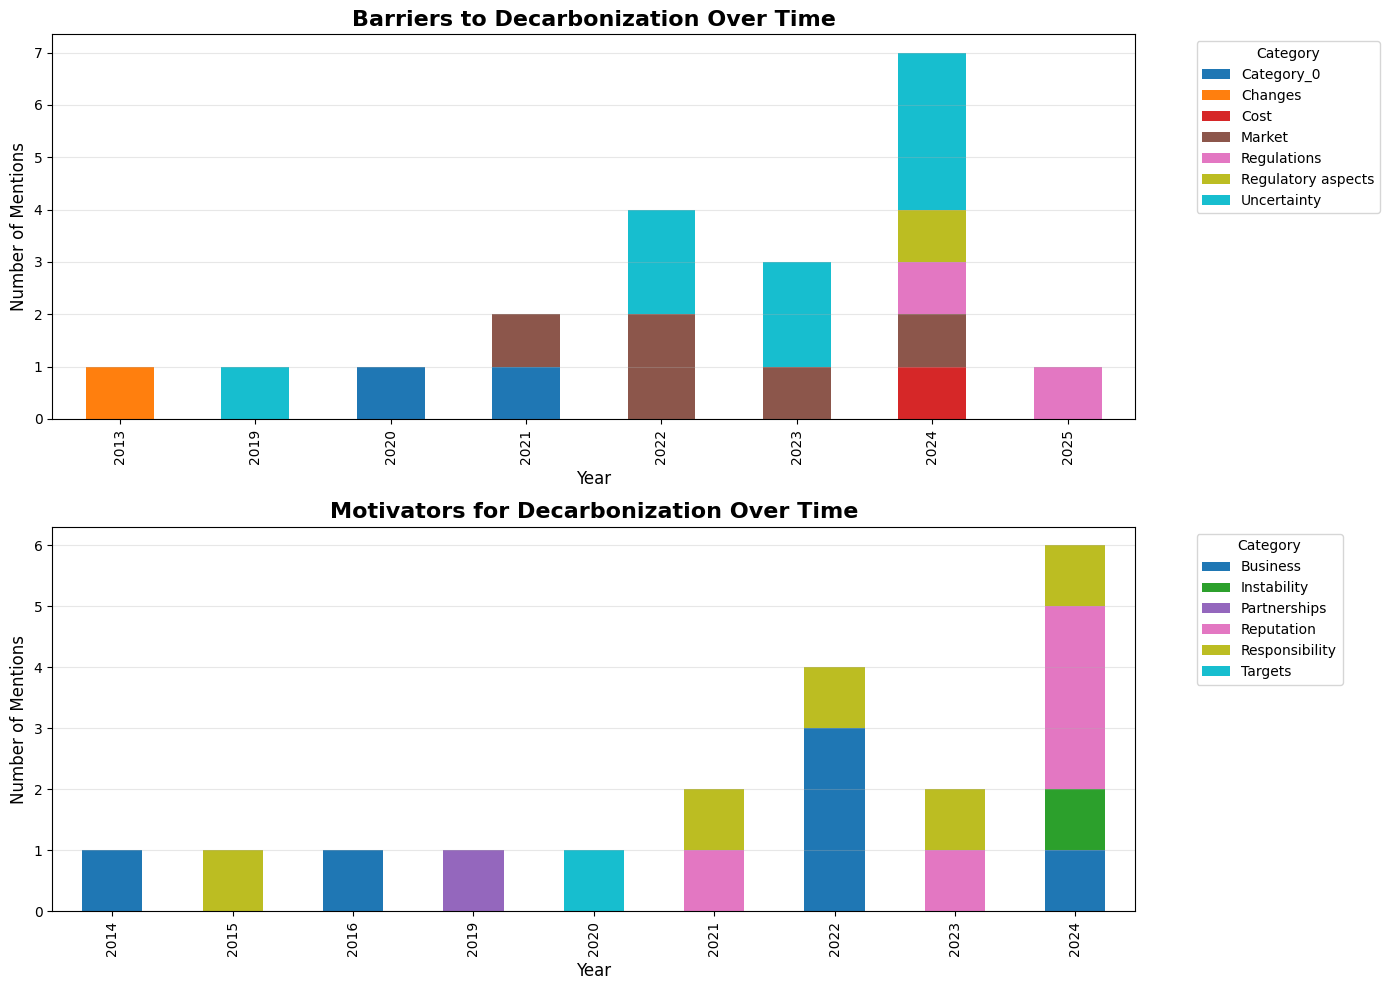

In [14]:
# Step 5: Create visualization
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Barriers chart
barriers_yearly.plot(kind='bar', stacked=True, ax=ax1, colormap='tab10')
ax1.set_title('Barriers to Decarbonization Over Time', fontsize=16, fontweight='bold')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of Mentions', fontsize=12)
ax1.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(axis='y', alpha=0.3)

# Motivators chart
motivators_yearly.plot(kind='bar', stacked=True, ax=ax2, colormap='tab10')
ax2.set_title('Motivators for Decarbonization Over Time', fontsize=16, fontweight='bold')
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Number of Mentions', fontsize=12)
ax2.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('decarbonization_timeline.png', dpi=300, bbox_inches='tight')
plt.show()


✅ Chart saved as 'decarbonization_timeline_lines.png'


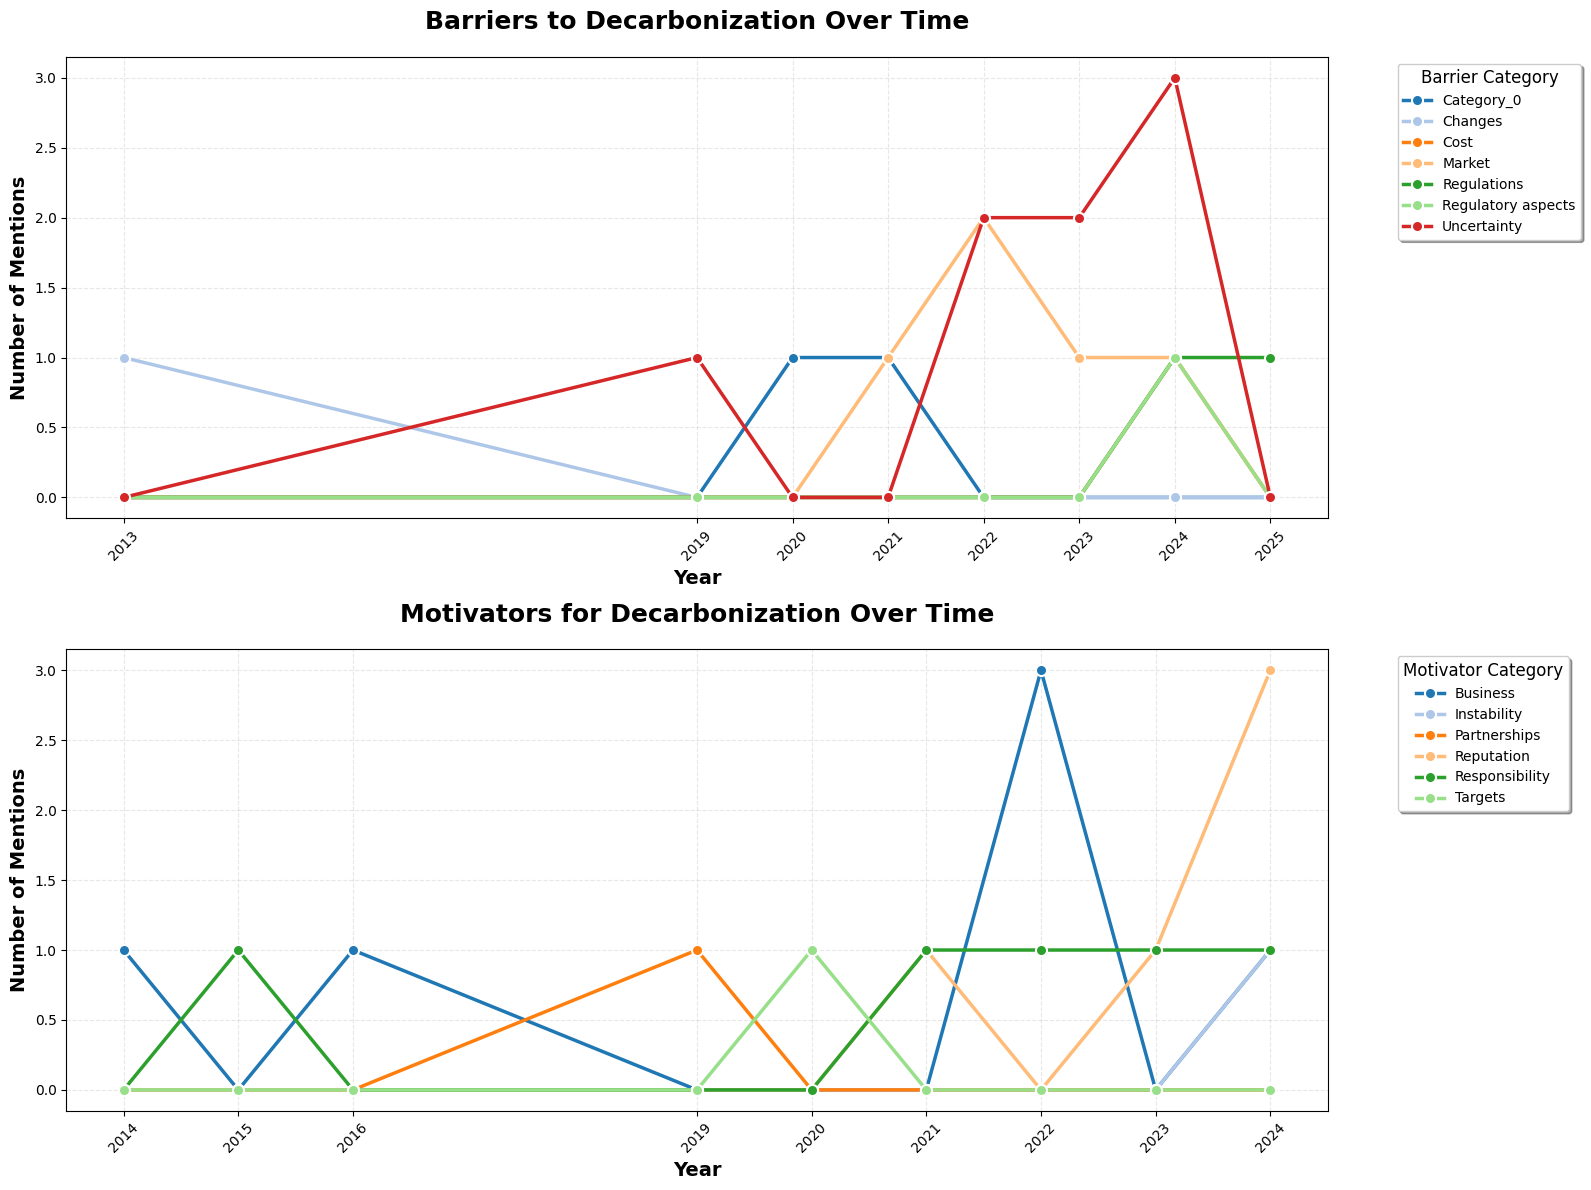

In [ ]:
# line charts with dots

import matplotlib.pyplot as plt
import numpy as np

# Step 5: Create line charts with dots
def create_line_charts(barriers_yearly, motivators_yearly):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

    # Define color palette
    colors = plt.cm.tab20(np.linspace(0, 1, 20))

    # ===== BARRIERS CHART =====
    barrier_categories = barriers_yearly.columns

    for idx, category in enumerate(barrier_categories):
        ax1.plot(
            barriers_yearly.index,
            barriers_yearly[category],
            marker='o',           # Dots
            markersize=8,         # Dot size
            linewidth=2.5,        # Line thickness
            label=category,
            color=colors[idx],
            markeredgecolor='white',  # White outline on dots
            markeredgewidth=1.5
        )

    ax1.set_title('Barriers to Decarbonization Over Time',
                  fontsize=18, fontweight='bold', pad=20)
    ax1.set_xlabel('Year', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Number of Mentions', fontsize=14, fontweight='bold')
    ax1.legend(title='Barrier Category',
               bbox_to_anchor=(1.05, 1),
               loc='upper left',
               fontsize=10,
               title_fontsize=12,
               frameon=True,
               shadow=True)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_xticks(barriers_yearly.index)
    ax1.set_xticklabels(barriers_yearly.index, rotation=45)

    # ===== MOTIVATORS CHART =====
    motivator_categories = motivators_yearly.columns

    for idx, category in enumerate(motivator_categories):
        ax2.plot(
            motivators_yearly.index,
            motivators_yearly[category],
            marker='o',           # Dots
            markersize=8,         # Dot size
            linewidth=2.5,        # Line thickness
            label=category,
            color=colors[idx],
            markeredgecolor='white',  # White outline on dots
            markeredgewidth=1.5
        )

    ax2.set_title('Motivators for Decarbonization Over Time',
                  fontsize=18, fontweight='bold', pad=20)
    ax2.set_xlabel('Year', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Number of Mentions', fontsize=14, fontweight='bold')
    ax2.legend(title='Motivator Category',
               bbox_to_anchor=(1.05, 1),
               loc='upper left',
               fontsize=10,
               title_fontsize=12,
               frameon=True,
               shadow=True)
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.set_xticks(motivators_yearly.index)
    ax2.set_xticklabels(motivators_yearly.index, rotation=45)

    plt.tight_layout()
    plt.savefig('decarbonization_timeline_lines.png', dpi=300, bbox_inches='tight')
    print("\n✅ Chart saved as 'decarbonization_timeline_lines.png'")
    plt.show()

# Create the charts
create_line_charts(barriers_yearly, motivators_yearly)

## with Keywords

In [ ]:
import os
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from tqdm import tqdm
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# # Disable tokenizers warning
# os.environ["TOKENIZERS_PARALLELISM"] = "false"

# # Step 1: Load all CSV files
# def load_data(folder_path, file_type='barriers'):
#     print(f"\n📂 Loading {file_type} data...")
#     all_data = []
#     files = [f for f in os.listdir(folder_path) if f.startswith(file_type) and f.endswith('.csv')]

#     for filename in tqdm(files, desc="Reading CSV files"):
#         df = pd.read_csv(os.path.join(folder_path, filename))
#         # Filter out NO_BARRIERS_FOUND / NO_MOTIVATORS_FOUND
#         df = df[~df[file_type].str.contains('NO_', na=False)]
#         all_data.append(df)

#     result = pd.concat(all_data, ignore_index=True)
#     print(f"✅ Loaded {len(result)} {file_type} entries")
#     return result

# barriers_df = load_data('decarbonisation_table', 'barriers')
# motivators_df = load_data('decarbonisation_table', 'motivators')

# Step 2+3: Embeddings + Clustering (OPTIMIZED)
print("\n🤖 Loading sentence transformer model...")
# Use smaller, faster model or GPU if available
model = SentenceTransformer('all-MiniLM-L6-v2')

# Check if GPU is available
import torch
if torch.cuda.is_available():
    model = model.to('cuda')
    print("✅ Using GPU for encoding")
else:
    print("⚠️  Using CPU for encoding (slower)")

def cluster_and_categorize(df, text_column, n_clusters=8):
    print(f"\n🔄 Processing {len(df)} texts...")

    # Get embeddings with progress bar and batch processing
    texts = df[text_column].tolist()

    print("🧮 Generating embeddings...")
    embeddings = model.encode(
        texts,
        batch_size=32,  # Process in batches for efficiency
        show_progress_bar=True,
        convert_to_numpy=True
    )

    # Cluster
    print(f"📊 Clustering into {n_clusters} categories...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

    # Add progress for clustering (it's fast but nice to see)
    with tqdm(total=1, desc="K-means clustering") as pbar:
        clusters = kmeans.fit_predict(embeddings)
        pbar.update(1)

    df['cluster'] = clusters

    # Analyze clusters with keywords
    from sklearn.feature_extraction.text import TfidfVectorizer

    print("\n📝 Analyzing clusters...")
    cluster_names = {}

    for i in tqdm(range(n_clusters), desc="Labeling clusters"):
        cluster_texts = df[df['cluster'] == i][text_column]

        # Get top keywords
        vectorizer = TfidfVectorizer(max_features=5, stop_words='english')
        try:
            tfidf_matrix = vectorizer.fit_transform(cluster_texts)
            feature_names = vectorizer.get_feature_names_out()
            keywords_str = ' '.join(feature_names).lower()

            # Auto-label based on keywords
            if any(word in keywords_str for word in ['cost', 'capital', 'financial', 'investment', 'funding']):
                label = 'Financial'
            elif any(word in keywords_str for word in ['policy', 'regulation', 'government', 'regulatory']):
                label = 'Policy/Regulatory'
            elif any(word in keywords_str for word in ['technology', 'infrastructure', 'hydrogen', 'technical']):
                label = 'Technical/Infrastructure'
            elif any(word in keywords_str for word in ['market', 'competition', 'customer', 'demand']):
                label = 'Market'
            elif any(word in keywords_str for word in ['emissions', 'carbon', 'climate', 'environmental', 'goals']):
                label = 'Environmental Goals'
            elif any(word in keywords_str for word in ['water', 'resource', 'scarcity']):
                label = 'Water/Resource'
            elif any(word in keywords_str for word in ['skills', 'workforce', 'training']):
                label = 'Workforce/Skills'
            else:
                label = f"Category_{i}"

            cluster_names[i] = label

        except:
            cluster_names[i] = f"Category_{i}"

    df['category'] = df['cluster'].map(cluster_names)

    # Show summary
    print("\n📋 Cluster Summary:")
    for i, name in cluster_names.items():
        count = len(df[df['cluster'] == i])
        print(f"  {name}: {count} items")

    return df

barriers_df = cluster_and_categorize(barriers_df, 'barriers', n_clusters=10)
motivators_df = cluster_and_categorize(motivators_df, 'motivators', n_clusters=8)

# Step 4: Aggregate by year
print("\n📈 Aggregating by year...")
def aggregate_by_year(df, category_col='category'):
    yearly_counts = df.groupby(['year', category_col]).size().reset_index(name='count')
    return yearly_counts.pivot(index='year', columns=category_col, values='count').fillna(0)

barriers_yearly = aggregate_by_year(barriers_df, 'category')
motivators_yearly = aggregate_by_year(motivators_df, 'category')

print("✅ Processing complete!")


🤖 Loading sentence transformer model...
⚠️  Using CPU for encoding (slower)

🔄 Processing 20 texts...
🧮 Generating embeddings...


Batches: 100%|██████████| 1/1 [00:00<00:00,  3.43it/s]


📊 Clustering into 10 categories...


K-means clustering: 100%|██████████| 1/1 [00:00<00:00, 22.48it/s]



📝 Analyzing clusters...


...

📊 Clustering into 8 categories...


K-means clustering: 100%|██████████| 1/1 [00:00<00:00, 64.01it/s]



📝 Analyzing clusters...


Labeling clusters: 100%|██████████| 8/8 [00:00<00:00, 646.51it/s]


📋 Cluster Summary:
  Environmental Goals: 5 items
  Financial: 1 items
  Category_2: 1 items
  Environmental Goals: 4 items
  Category_4: 1 items
  Policy/Regulatory: 4 items
  Category_6: 1 items
  Environmental Goals: 2 items

📈 Aggregating by year...
✅ Processing complete!



✅ Chart saved as 'decarbonization_timeline_lines.png'


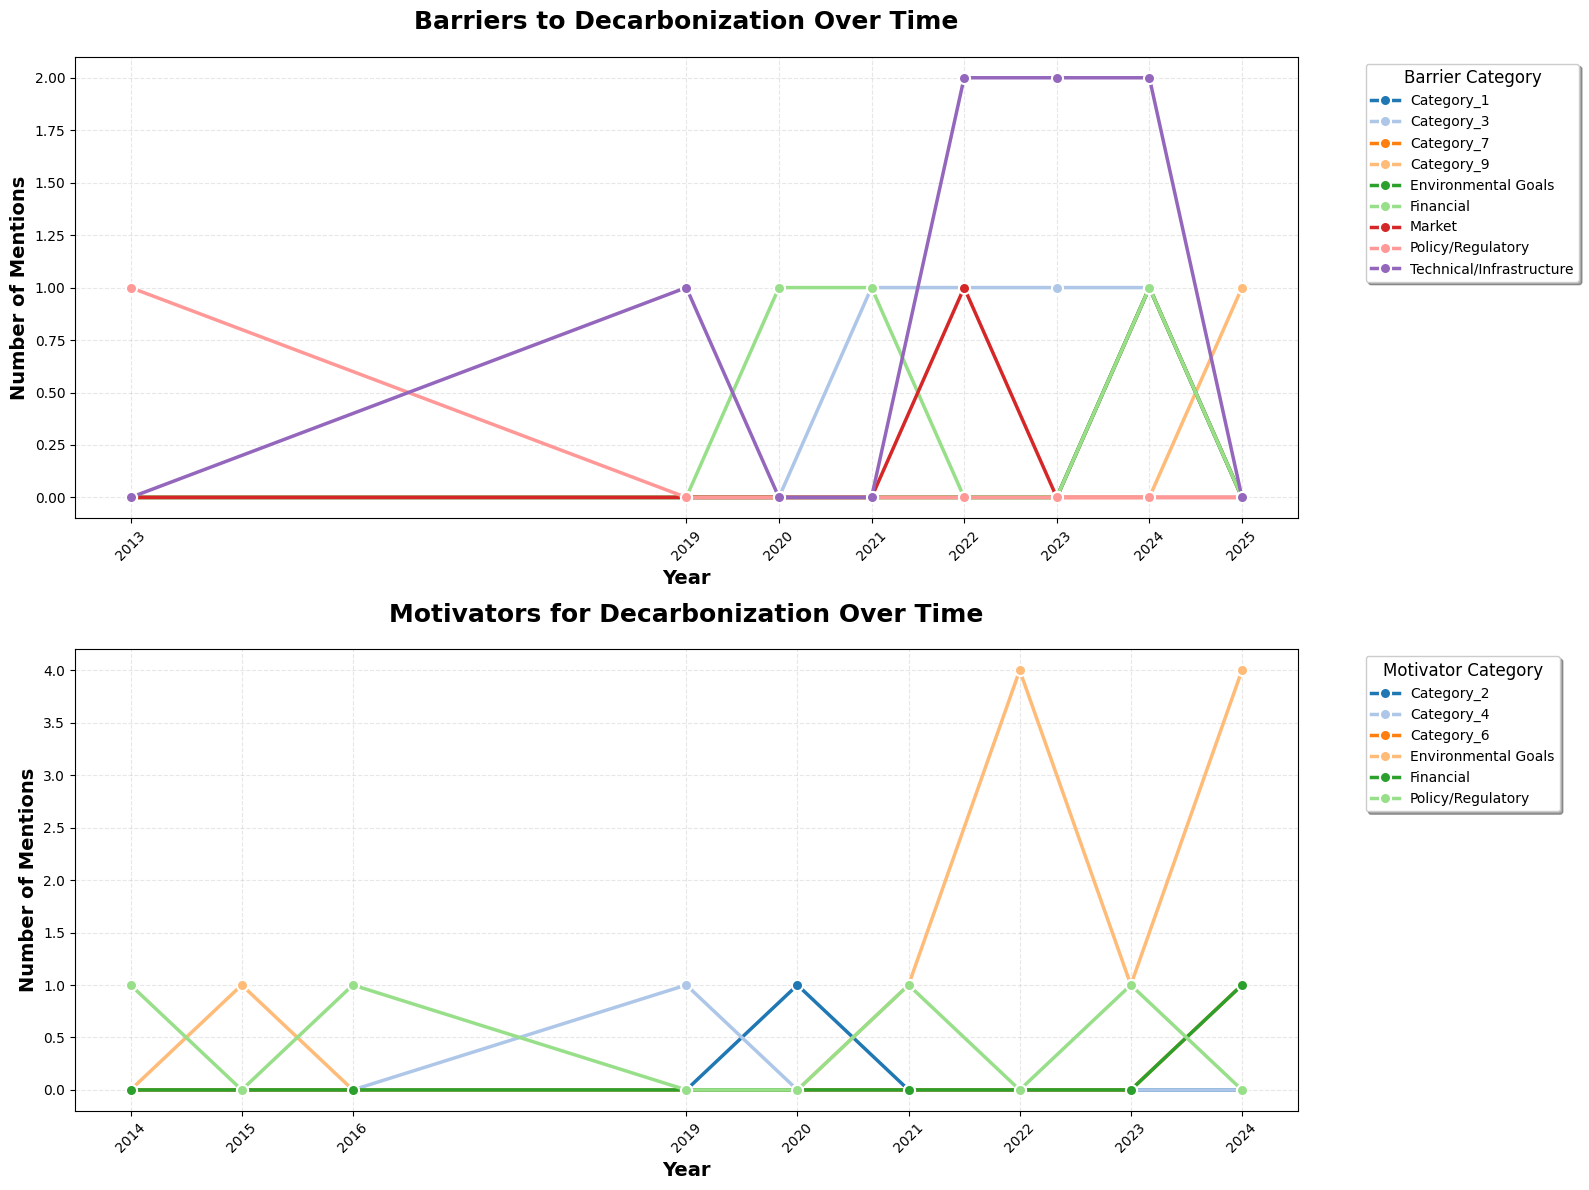

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Step 5: Create line charts with dots
def create_line_charts(barriers_yearly, motivators_yearly):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

    # Define color palette
    colors = plt.cm.tab20(np.linspace(0, 1, 20))

    # ===== BARRIERS CHART =====
    barrier_categories = barriers_yearly.columns

    for idx, category in enumerate(barrier_categories):
        ax1.plot(
            barriers_yearly.index,
            barriers_yearly[category],
            marker='o',           # Dots
            markersize=8,         # Dot size
            linewidth=2.5,        # Line thickness
            label=category,
            color=colors[idx],
            markeredgecolor='white',  # White outline on dots
            markeredgewidth=1.5
        )

    ax1.set_title('Barriers to Decarbonization Over Time',
                  fontsize=18, fontweight='bold', pad=20)
    ax1.set_xlabel('Year', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Number of Mentions', fontsize=14, fontweight='bold')
    ax1.legend(title='Barrier Category',
               bbox_to_anchor=(1.05, 1),
               loc='upper left',
               fontsize=10,
               title_fontsize=12,
               frameon=True,
               shadow=True)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_xticks(barriers_yearly.index)
    ax1.set_xticklabels(barriers_yearly.index, rotation=45)

    # ===== MOTIVATORS CHART =====
    motivator_categories = motivators_yearly.columns

    for idx, category in enumerate(motivator_categories):
        ax2.plot(
            motivators_yearly.index,
            motivators_yearly[category],
            marker='o',           # Dots
            markersize=8,         # Dot size
            linewidth=2.5,        # Line thickness
            label=category,
            color=colors[idx],
            markeredgecolor='white',  # White outline on dots
            markeredgewidth=1.5
        )

    ax2.set_title('Motivators for Decarbonization Over Time',
                  fontsize=18, fontweight='bold', pad=20)
    ax2.set_xlabel('Year', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Number of Mentions', fontsize=14, fontweight='bold')
    ax2.legend(title='Motivator Category',
               bbox_to_anchor=(1.05, 1),
               loc='upper left',
               fontsize=10,
               title_fontsize=12,
               frameon=True,
               shadow=True)
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.set_xticks(motivators_yearly.index)
    ax2.set_xticklabels(motivators_yearly.index, rotation=45)

    plt.tight_layout()
    plt.savefig('decarbonization_timeline_lines.png', dpi=300, bbox_inches='tight')
    print("\n✅ Chart saved as 'decarbonization_timeline_lines.png'")
    plt.show()

# Create the charts
create_line_charts(barriers_yearly, motivators_yearly)

## topic modeling with bert

In [1]:
!pip install bertopic

In [ ]:
# If you want more/fewer topics
n_topics=8  # Change to 8, 12, 15, etc.

# If topics are too small/fragmented
min_topic_size=10  # Increase to merge small topics

# For faster processing (less accuracy)
calculate_probabilities=False  # Already set

# For GPU acceleration
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
topic_model = BERTopic(embedding_model=embedding_model)

In [7]:
# If you want more/fewer topics
n_topics=8  # Change to 8, 12, 15, etc.

# If topics are too small/fragmented
min_topic_size=10  # Increase to merge small topics

DECARBONIZATION BARRIERS & MOTIVATORS ANALYSIS

📂 Loading barriers data...


Reading CSV files: 100%|██████████| 15/15 [00:00<00:00, 685.59it/s]


✅ Loaded 20 barriers entries

📂 Loading motivators data...


Reading CSV files: 100%|██████████| 15/15 [00:00<00:00, 1657.43it/s]
2025-12-16 21:35:22,234 - BERTopic - Embedding - Transforming documents to embeddings.


✅ Loaded 19 motivators entries

🤖 Running BERTopic on 20 barriers...
🔄 Fitting topic model (this may take a few minutes)...


Batches: 100%|██████████| 1/1 [00:00<00:00,  3.35it/s]
2025-12-16 21:35:24,953 - BERTopic - Embedding - Completed ✓
2025-12-16 21:35:24,954 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-16 21:35:25,027 - BERTopic - Dimensionality - Completed ✓
2025-12-16 21:35:25,027 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-16 21:35:25,029 - BERTopic - Cluster - Completed ✓
2025-12-16 21:35:25,030 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-12-16 21:35:25,043 - BERTopic - Representation - Completed ✓
2025-12-16 21:35:25,043 - BERTopic - Topic reduction - Reducing number of topics
2025-12-16 21:35:25,044 - BERTopic - Topic reduction - Number of topics (10) is equal or higher than the clustered topics(1).
2025-12-16 21:35:25,044 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-16 21:35:25,065 - BERTopic - Representation - Completed ✓
2025-12-16 21:35:25,08


✅ Identified 0 topics

📋 Topic Summary:
--------------------------------------------------------------------------------

📊 Final Category Distribution:
category
Other    20
Name: count, dtype: int64

🤖 Running BERTopic on 19 motivators...
🔄 Fitting topic model (this may take a few minutes)...


Batches: 100%|██████████| 1/1 [00:00<00:00,  7.54it/s]
2025-12-16 21:35:27,556 - BERTopic - Embedding - Completed ✓
2025-12-16 21:35:27,556 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-16 21:35:27,601 - BERTopic - Dimensionality - Completed ✓
2025-12-16 21:35:27,601 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-16 21:35:27,603 - BERTopic - Cluster - Completed ✓
2025-12-16 21:35:27,603 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-12-16 21:35:27,608 - BERTopic - Representation - Completed ✓
2025-12-16 21:35:27,608 - BERTopic - Topic reduction - Reducing number of topics
2025-12-16 21:35:27,608 - BERTopic - Topic reduction - Number of topics (8) is equal or higher than the clustered topics(1).
2025-12-16 21:35:27,608 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-16 21:35:27,621 - BERTopic - Representation - Completed ✓



✅ Identified 0 topics

📋 Topic Summary:
--------------------------------------------------------------------------------

📊 Final Category Distribution:
category
Other    19
Name: count, dtype: int64

📈 Aggregating data by year...
✅ Aggregation complete!

Barriers shape: (8, 1)
Motivators shape: (9, 1)

🎨 Creating visualizations...
✅ Chart saved as 'decarbonization_timeline_lines.png'


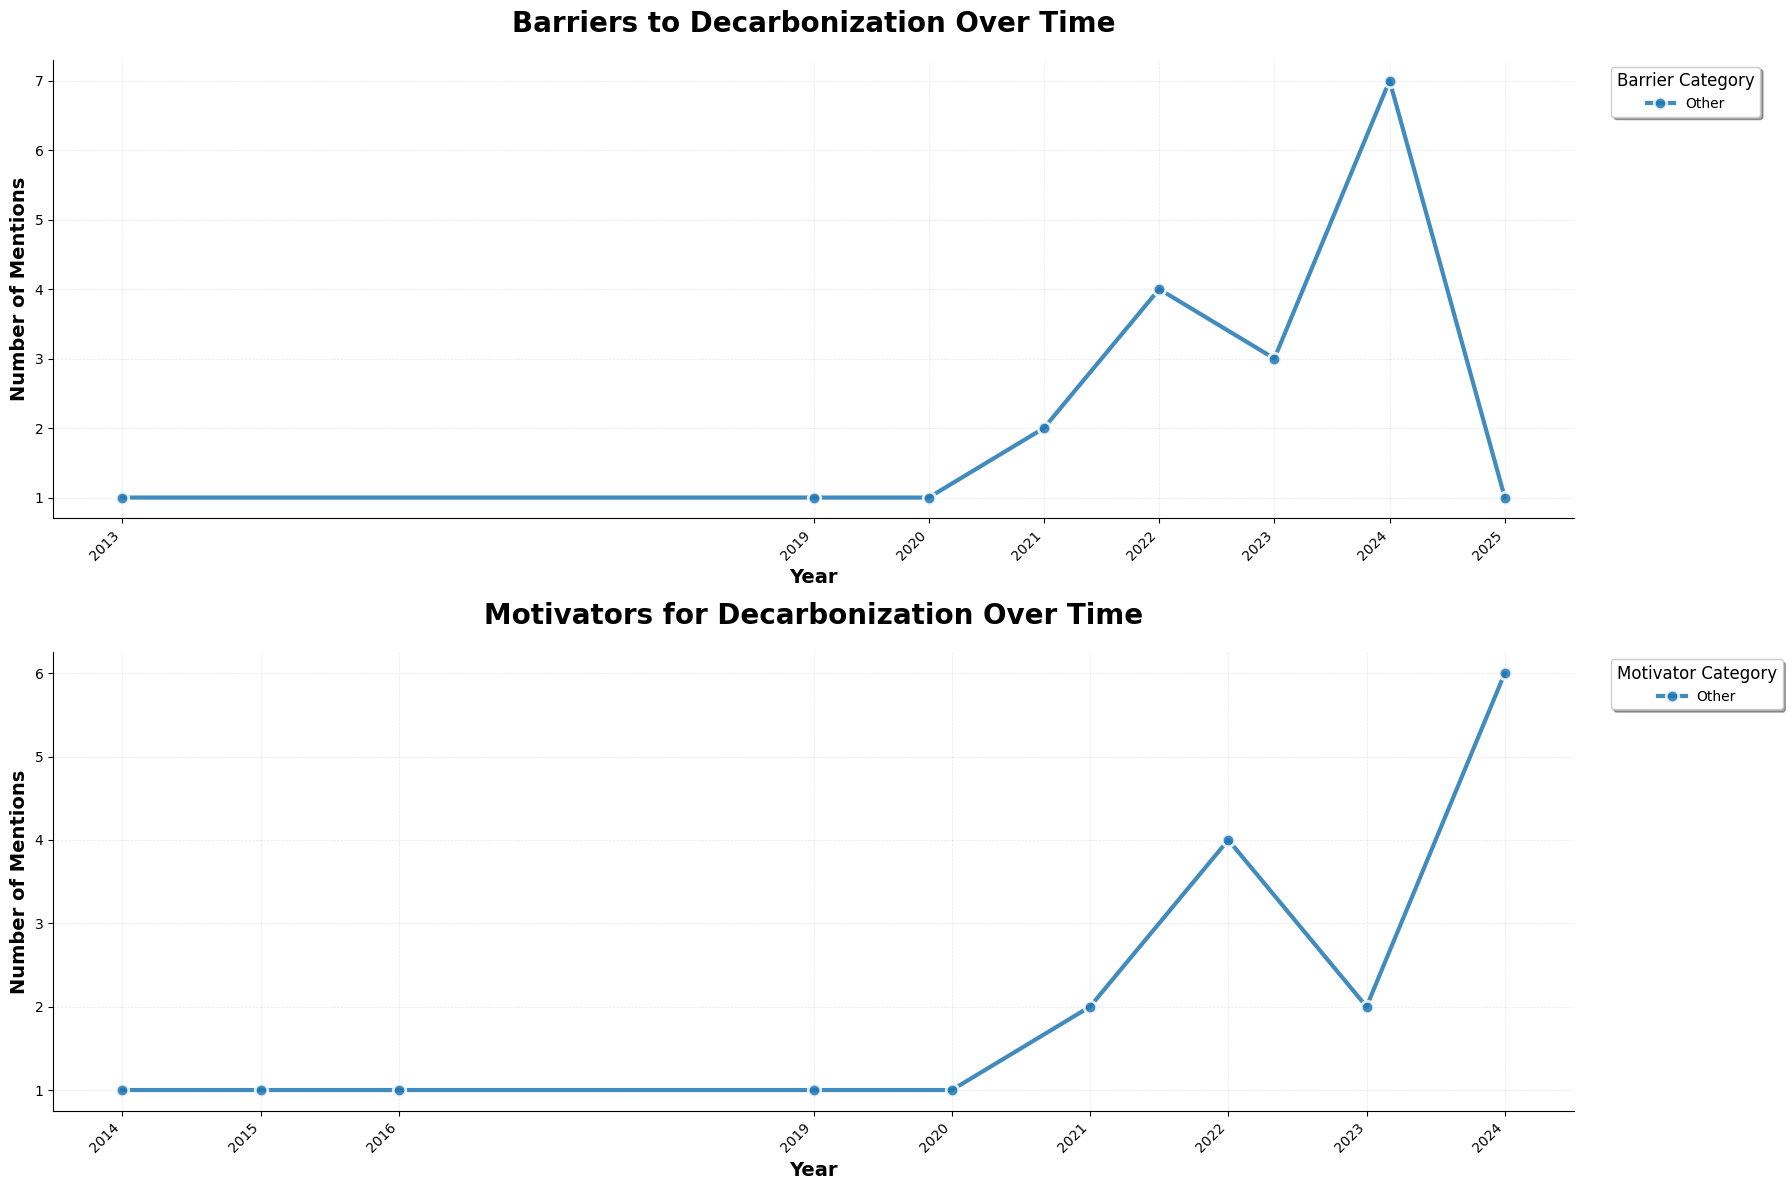


💾 Saving processed data...
✅ Saved categorized data to CSV files

✨ ANALYSIS COMPLETE!


In [ ]:
import os
import pandas as pd
from bertopic import BERTopic
from tqdm import tqdm
import warnings
import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings('ignore')
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Step 1: Load all CSV files
def load_data(folder_path, file_type='barriers'):
    print(f"\n📂 Loading {file_type} data...")
    all_data = []
    files = [f for f in os.listdir(folder_path) if f.startswith(file_type) and f.endswith('.csv')]

    for filename in tqdm(files, desc="Reading CSV files"):
        df = pd.read_csv(os.path.join(folder_path, filename))
        # Filter out NO_BARRIERS_FOUND / NO_MOTIVATORS_FOUND
        df = df[~df[file_type].str.contains('NO_', na=False)]
        all_data.append(df)

    result = pd.concat(all_data, ignore_index=True)
    print(f"✅ Loaded {len(result)} {file_type} entries")
    return result

print("=" * 60)
print("DECARBONIZATION BARRIERS & MOTIVATORS ANALYSIS")
print("=" * 60)

barriers_df = load_data('decarbonisation_tables', 'barriers')
motivators_df = load_data('decarbonisation_tables', 'motivators')

# Step 2+3: Topic Modeling with BERTopic
def topic_modeling_categorization(df, text_column, n_topics=10, topic_type='barriers'):
    print(f"\n🤖 Running BERTopic on {len(df)} {topic_type}...")

    texts = df[text_column].tolist()

    # Configure BERTopic
    topic_model = BERTopic(
        language="english",
        nr_topics=n_topics,  # Target number of topics
        min_topic_size=5,    # Minimum documents per topic
        verbose=True,
        calculate_probabilities=False  # Faster without probabilities
    )

    # Fit the model
    print("🔄 Fitting topic model (this may take a few minutes)...")
    topics, probabilities = topic_model.fit_transform(texts)

    # Add topics to dataframe
    df['topic'] = topics

    # Get topic info
    topic_info = topic_model.get_topic_info()
    print(f"\n✅ Identified {len(topic_info) - 1} topics")  # -1 for outlier topic

    # Map topics to readable categories
    print("\n📋 Topic Summary:")
    print("-" * 80)

    topic_mapping = {}
    for idx, row in topic_info.iterrows():
        topic_id = row['Topic']

        if topic_id == -1:  # Outlier topic
            topic_mapping[topic_id] = 'Other'
            continue

        # Get top words for this topic
        top_words = topic_model.get_topic(topic_id)
        if top_words:
            top_5_words = [word for word, score in top_words[:5]]
            keywords_str = ' '.join(top_5_words).lower()

            # Auto-categorize based on keywords
            if topic_type == 'barriers':
                category = categorize_barrier_topic(keywords_str, top_5_words)
            else:
                category = categorize_motivator_topic(keywords_str, top_5_words)

            topic_mapping[topic_id] = category

            # Print topic summary
            print(f"Topic {topic_id}: {category}")
            print(f"  Keywords: {', '.join(top_5_words)}")
            print(f"  Count: {row['Count']} documents")
            print()

    # Apply mapping
    df['category'] = df['topic'].map(topic_mapping)

    # Show category distribution
    print("\n📊 Final Category Distribution:")
    print(df['category'].value_counts())

    return df, topic_model

def categorize_barrier_topic(keywords_str, top_words):
    """Map topic keywords to barrier categories"""
    keywords_lower = [w.lower() for w in top_words]

    # Financial
    if any(word in keywords_str for word in ['cost', 'capital', 'investment', 'funding', 'expensive', 'financial', 'price']):
        return 'Financial'

    # Policy/Regulatory
    elif any(word in keywords_str for word in ['policy', 'regulation', 'government', 'permit', 'regulatory', 'legal', 'cbam', 'ets']):
        return 'Policy/Regulatory'

    # Technical/Infrastructure
    elif any(word in keywords_str for word in ['technology', 'infrastructure', 'hydrogen', 'technical', 'ccus', 'energy', 'electricity']):
        return 'Technical/Infrastructure'

    # Market
    elif any(word in keywords_str for word in ['market', 'competition', 'customer', 'demand', 'leakage', 'pricing', 'competitive']):
        return 'Market'

    # Water/Resource
    elif any(word in keywords_str for word in ['water', 'resource', 'scarcity', 'supply', 'availability']):
        return 'Water/Resource'

    # Workforce/Skills
    elif any(word in keywords_str for word in ['skills', 'workforce', 'training', 'talent', 'labor', 'employee']):
        return 'Workforce/Skills'

    # Physical Climate Risk
    elif any(word in keywords_str for word in ['climate', 'weather', 'physical', 'adaptation', 'disaster', 'risk']):
        return 'Physical Climate Risk'

    # Reputation/Social
    elif any(word in keywords_str for word in ['reputation', 'stakeholder', 'opposition', 'acceptance', 'social', 'public']):
        return 'Reputation/Social'

    # Economic/Timing
    elif any(word in keywords_str for word in ['delay', 'timing', 'timeline', 'economic', 'uncertainty', 'pace']):
        return 'Economic/Timing'

    # Strategic Commitment
    elif any(word in keywords_str for word in ['commitment', 'ambition', 'strategy', 'shareholder', 'target']):
        return 'Strategic Commitment'

    else:
        return f"Theme_{keywords_lower[0]}"

def categorize_motivator_topic(keywords_str, top_words):
    """Map topic keywords to motivator categories"""
    keywords_lower = [w.lower() for w in top_words]

    # Environmental Goals
    if any(word in keywords_str for word in ['emissions', 'carbon', 'climate', 'environmental', 'sustainability', 'decarboni', 'net', 'zero', 'paris']):
        return 'Environmental Goals'

    # Policy/Regulatory
    elif any(word in keywords_str for word in ['policy', 'regulation', 'compliance', 'government', 'support', 'framework', 'regulatory']):
        return 'Policy/Regulatory'

    # Technical/Infrastructure
    elif any(word in keywords_str for word in ['technology', 'innovation', 'hydrogen', 'renewable', 'technical', 'infrastructure', 'efficiency']):
        return 'Technical/Infrastructure'

    # Financial
    elif any(word in keywords_str for word in ['cost', 'funding', 'investment', 'subsidy', 'finance', 'financial', 'competitive']):
        return 'Financial'

    # Strategic Positioning
    elif any(word in keywords_str for word in ['competitive', 'leadership', 'future', 'resilience', 'transformation', 'strategy', 'positioning']):
        return 'Strategic Positioning'

    # Stakeholder Engagement
    elif any(word in keywords_str for word in ['stakeholder', 'community', 'customer', 'supplier', 'partnership', 'engagement', 'collaboration']):
        return 'Stakeholder Engagement'

    # Operational Benefits
    elif any(word in keywords_str for word in ['efficiency', 'optimization', 'waste', 'resource', 'productivity', 'operational', 'improvement']):
        return 'Operational Benefits'

    # Market
    elif any(word in keywords_str for word in ['market', 'demand', 'customer', 'premium', 'positioning', 'competitive']):
        return 'Market'

    # Transparency/Reporting
    elif any(word in keywords_str for word in ['reporting', 'disclosure', 'tcfd', 'transparency', 'esg', 'report']):
        return 'Transparency/Reporting'

    else:
        return f"Theme_{keywords_lower[0]}"

# Run topic modeling
barriers_df, barriers_model = topic_modeling_categorization(
    barriers_df,
    'barriers',
    n_topics=10,
    topic_type='barriers'
)

motivators_df, motivators_model = topic_modeling_categorization(
    motivators_df,
    'motivators',
    n_topics=8,
    topic_type='motivators'
)

# Step 4: Aggregate by year and category
print("\n📈 Aggregating data by year...")
def aggregate_by_year(df, category_col='category'):
    yearly_counts = df.groupby(['year', category_col]).size().reset_index(name='count')
    pivot_table = yearly_counts.pivot(index='year', columns=category_col, values='count').fillna(0)
    return pivot_table

barriers_yearly = aggregate_by_year(barriers_df, 'category')
motivators_yearly = aggregate_by_year(motivators_df, 'category')

print("✅ Aggregation complete!")
print(f"\nBarriers shape: {barriers_yearly.shape}")
print(f"Motivators shape: {motivators_yearly.shape}")

# Step 5: Create line charts with dots
def create_line_charts(barriers_yearly, motivators_yearly):
    print("\n🎨 Creating visualizations...")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 12))

    # Define color palette
    colors = plt.cm.tab20(np.linspace(0, 1, 20))

    # ===== BARRIERS CHART =====
    barrier_categories = barriers_yearly.columns

    for idx, category in enumerate(barrier_categories):
        ax1.plot(
            barriers_yearly.index,
            barriers_yearly[category],
            marker='o',
            markersize=9,
            linewidth=3,
            label=category,
            color=colors[idx],
            markeredgecolor='white',
            markeredgewidth=2,
            alpha=0.85
        )

    ax1.set_title('Barriers to Decarbonization Over Time',
                  fontsize=20, fontweight='bold', pad=20)
    ax1.set_xlabel('Year', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Number of Mentions', fontsize=14, fontweight='bold')
    ax1.legend(title='Barrier Category',
               bbox_to_anchor=(1.02, 1),
               loc='upper left',
               fontsize=10,
               title_fontsize=12,
               frameon=True,
               shadow=True,
               fancybox=True)
    ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax1.set_xticks(barriers_yearly.index)
    ax1.set_xticklabels(barriers_yearly.index, rotation=45, ha='right')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # ===== MOTIVATORS CHART =====
    motivator_categories = motivators_yearly.columns

    for idx, category in enumerate(motivator_categories):
        ax2.plot(
            motivators_yearly.index,
            motivators_yearly[category],
            marker='o',
            markersize=9,
            linewidth=3,
            label=category,
            color=colors[idx],
            markeredgecolor='white',
            markeredgewidth=2,
            alpha=0.85
        )

    ax2.set_title('Motivators for Decarbonization Over Time',
                  fontsize=20, fontweight='bold', pad=20)
    ax2.set_xlabel('Year', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Number of Mentions', fontsize=14, fontweight='bold')
    ax2.legend(title='Motivator Category',
               bbox_to_anchor=(1.02, 1),
               loc='upper left',
               fontsize=10,
               title_fontsize=12,
               frameon=True,
               shadow=True,
               fancybox=True)
    ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax2.set_xticks(motivators_yearly.index)
    ax2.set_xticklabels(motivators_yearly.index, rotation=45, ha='right')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig('decarbonization_timeline_lines.png', dpi=300, bbox_inches='tight')
    print("✅ Chart saved as 'decarbonization_timeline_lines.png'")
    plt.show()

create_line_charts(barriers_yearly, motivators_yearly)

# Optional: Save the processed data
print("\n💾 Saving processed data...")
barriers_df.to_csv('barriers_categorized.csv', index=False)
motivators_df.to_csv('motivators_categorized.csv', index=False)
print("✅ Saved categorized data to CSV files")

print("\n" + "=" * 60)
print("✨ ANALYSIS COMPLETE!")
print("=" * 60)

In [ ]:
import os
import pandas as pd
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from tqdm import tqdm
import warnings
import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings('ignore')
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Step 1: Load all CSV files
def load_data(folder_path, file_type='barriers'):
    print(f"\n📂 Loading {file_type} data...")
    all_data = []
    files = [f for f in os.listdir(folder_path) if f.startswith(file_type) and f.endswith('.csv')]

    for filename in tqdm(files, desc="Reading CSV files"):
        df = pd.read_csv(os.path.join(folder_path, filename))
        # Filter out NO_BARRIERS_FOUND / NO_MOTIVATORS_FOUND
        df = df[~df[file_type].str.contains('NO_', na=False)]
        all_data.append(df)

    result = pd.concat(all_data, ignore_index=True)
    print(f"✅ Loaded {len(result)} {file_type} entries")
    return result

print("=" * 60)
print("DECARBONIZATION BARRIERS & MOTIVATORS ANALYSIS")
print("=" * 60)

barriers_df = load_data('decarbonisation_tables', 'barriers')
motivators_df = load_data('decarbonisation_tables', 'motivators')

# Step 2+3: Improved Topic Modeling
def topic_modeling_categorization(df, text_column, n_topics=8, topic_type='barriers'):
    print(f"\n🤖 Running BERTopic on {len(df)} {topic_type}...")

    texts = df[text_column].tolist()

    # Use better parameters for small/diverse datasets
    embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

    # Vectorizer with better parameters
    vectorizer_model = CountVectorizer(
        ngram_range=(1, 2),  # Include bigrams
        stop_words="english",
        min_df=1,  # More lenient
        max_df=0.95
    )

    # Configure BERTopic with more lenient settings
    topic_model = BERTopic(
        embedding_model=embedding_model,
        vectorizer_model=vectorizer_model,
        language="english",
        nr_topics=n_topics,
        min_topic_size=3,  # Much smaller - was 5
        verbose=False,
        calculate_probabilities=False,
        low_memory=True
    )

    # Fit the model
    print("🔄 Fitting topic model...")
    topics, probabilities = topic_model.fit_transform(texts)

    # Debug: Check topic distribution
    unique_topics = pd.Series(topics).value_counts()
    print(f"\n🔍 Topic distribution:")
    print(unique_topics)

    # If too many outliers, try to reduce topics
    if topics.count(-1) > len(topics) * 0.5:
        print("\n⚠️  Too many outliers detected. Reducing topics automatically...")
        topic_model.reduce_outliers(texts, topics, strategy="embeddings")
        topics = topic_model.update_topics(texts, topics)

    # Add topics to dataframe
    df['topic'] = topics

    # Get topic info
    topic_info = topic_model.get_topic_info()
    print(f"\n✅ Identified {len(topic_info) - 1} topics (excluding outliers)")

    # Map topics to readable categories
    print("\n📋 Topic Summary:")
    print("-" * 80)

    topic_mapping = {}
    category_counts = {}

    for idx, row in topic_info.iterrows():
        topic_id = row['Topic']

        if topic_id == -1:  # Outlier topic
            # Try to manually categorize outliers
            outlier_texts = df[df['topic'] == -1][text_column]
            for text in outlier_texts:
                if topic_type == 'barriers':
                    category = manual_categorize_barrier(text)
                else:
                    category = manual_categorize_motivator(text)

                # Store for mapping later
                outlier_idx = df[df[text_column] == text].index[0]
                df.at[outlier_idx, 'manual_category'] = category
            continue

        # Get top words for this topic
        top_words = topic_model.get_topic(topic_id)
        if top_words:
            top_5_words = [word for word, score in top_words[:5]]
            keywords_str = ' '.join(top_5_words).lower()

            # Auto-categorize based on keywords
            if topic_type == 'barriers':
                category = categorize_barrier_topic(keywords_str, top_5_words)
            else:
                category = categorize_motivator_topic(keywords_str, top_5_words)

            topic_mapping[topic_id] = category
            category_counts[category] = category_counts.get(category, 0) + row['Count']

            # Print topic summary
            print(f"Topic {topic_id}: {category}")
            print(f"  Keywords: {', '.join(top_5_words)}")
            print(f"  Count: {row['Count']} documents")
            print()

    # Apply mapping for non-outliers
    df['category'] = df['topic'].map(topic_mapping)

    # Use manual categorization for outliers
    if 'manual_category' in df.columns:
        df['category'] = df['category'].fillna(df['manual_category'])
    else:
        # Fallback: categorize remaining outliers
        df['category'] = df['category'].fillna('Other')

    # Show final category distribution
    print("\n📊 Final Category Distribution:")
    print(df['category'].value_counts())

    # Check if we still have mostly "Other"
    if (df['category'] == 'Other').sum() > len(df) * 0.7:
        print("\n⚠️  WARNING: Most items categorized as 'Other'")
        print("   Falling back to keyword-based categorization...")
        df = fallback_keyword_categorization(df, text_column, topic_type)
        print("\n📊 Updated Category Distribution:")
        print(df['category'].value_counts())

    return df, topic_model

def manual_categorize_barrier(text):
    """Manually categorize individual barrier texts"""
    text_lower = text.lower()

    if any(word in text_lower for word in ['cost', 'capital', 'investment', 'funding', 'expensive', 'financial']):
        return 'Financial'
    elif any(word in text_lower for word in ['policy', 'regulation', 'government', 'permit', 'regulatory']):
        return 'Policy/Regulatory'
    elif any(word in text_lower for word in ['technology', 'infrastructure', 'hydrogen', 'technical', 'ccus']):
        return 'Technical/Infrastructure'
    elif any(word in text_lower for word in ['market', 'competition', 'customer', 'demand']):
        return 'Market'
    elif any(word in text_lower for word in ['water', 'resource', 'scarcity']):
        return 'Water/Resource'
    elif any(word in text_lower for word in ['skills', 'workforce', 'training']):
        return 'Workforce/Skills'
    elif any(word in text_lower for word in ['climate', 'weather', 'physical', 'adaptation']):
        return 'Physical Climate Risk'
    elif any(word in text_lower for word in ['reputation', 'stakeholder', 'opposition', 'acceptance']):
        return 'Reputation/Social'
    elif any(word in text_lower for word in ['delay', 'timing', 'economic', 'uncertainty']):
        return 'Economic/Timing'
    elif any(word in text_lower for word in ['commitment', 'ambition', 'strategy']):
        return 'Strategic Commitment'
    else:
        return 'Other'

def manual_categorize_motivator(text):
    """Manually categorize individual motivator texts"""
    text_lower = text.lower()

    if any(word in text_lower for word in ['emissions', 'carbon', 'climate', 'environmental', 'sustainability', 'net-zero', 'decarboni']):
        return 'Environmental Goals'
    elif any(word in text_lower for word in ['policy', 'regulation', 'compliance', 'government']):
        return 'Policy/Regulatory'
    elif any(word in text_lower for word in ['technology', 'innovation', 'hydrogen', 'renewable']):
        return 'Technical/Infrastructure'
    elif any(word in text_lower for word in ['cost', 'funding', 'investment', 'subsidy', 'financial']):
        return 'Financial'
    elif any(word in text_lower for word in ['competitive', 'leadership', 'future', 'resilience', 'transformation']):
        return 'Strategic Positioning'
    elif any(word in text_lower for word in ['stakeholder', 'community', 'customer', 'supplier', 'partnership']):
        return 'Stakeholder Engagement'
    elif any(word in text_lower for word in ['efficiency', 'optimization', 'waste', 'productivity']):
        return 'Operational Benefits'
    elif any(word in text_lower for word in ['market', 'demand', 'premium']):
        return 'Market'
    elif any(word in text_lower for word in ['reporting', 'disclosure', 'tcfd', 'transparency']):
        return 'Transparency/Reporting'
    else:
        return 'Other'

def fallback_keyword_categorization(df, text_column, topic_type):
    """Fallback to simple keyword-based categorization"""
    print("   Using keyword-based approach...")

    if topic_type == 'barriers':
        df['category'] = df[text_column].apply(manual_categorize_barrier)
    else:
        df['category'] = df[text_column].apply(manual_categorize_motivator)

    return df

def categorize_barrier_topic(keywords_str, top_words):
    """Map topic keywords to barrier categories"""
    keywords_lower = [w.lower() for w in top_words]

    if any(word in keywords_str for word in ['cost', 'capital', 'investment', 'funding', 'expensive', 'financial', 'price']):
        return 'Financial'
    elif any(word in keywords_str for word in ['policy', 'regulation', 'government', 'permit', 'regulatory', 'legal', 'cbam']):
        return 'Policy/Regulatory'
    elif any(word in keywords_str for word in ['technology', 'infrastructure', 'hydrogen', 'technical', 'ccus', 'energy']):
        return 'Technical/Infrastructure'
    elif any(word in keywords_str for word in ['market', 'competition', 'customer', 'demand', 'leakage', 'competitive']):
        return 'Market'
    elif any(word in keywords_str for word in ['water', 'resource', 'scarcity', 'supply']):
        return 'Water/Resource'
    elif any(word in keywords_str for word in ['skills', 'workforce', 'training', 'talent']):
        return 'Workforce/Skills'
    elif any(word in keywords_str for word in ['climate', 'weather', 'physical', 'adaptation', 'disaster']):
        return 'Physical Climate Risk'
    elif any(word in keywords_str for word in ['reputation', 'stakeholder', 'opposition', 'acceptance', 'social']):
        return 'Reputation/Social'
    elif any(word in keywords_str for word in ['delay', 'timing', 'economic', 'uncertainty', 'pace']):
        return 'Economic/Timing'
    elif any(word in keywords_str for word in ['commitment', 'ambition', 'strategy', 'shareholder']):
        return 'Strategic Commitment'
    else:
        return f"Barrier_Theme"

def categorize_motivator_topic(keywords_str, top_words):
    """Map topic keywords to motivator categories"""
    keywords_lower = [w.lower() for w in top_words]

    if any(word in keywords_str for word in ['emissions', 'carbon', 'climate', 'environmental', 'sustainability', 'decarboni', 'net', 'zero']):
        return 'Environmental Goals'
    elif any(word in keywords_str for word in ['policy', 'regulation', 'compliance', 'government', 'support']):
        return 'Policy/Regulatory'
    elif any(word in keywords_str for word in ['technology', 'innovation', 'hydrogen', 'renewable', 'technical']):
        return 'Technical/Infrastructure'
    elif any(word in keywords_str for word in ['cost', 'funding', 'investment', 'subsidy', 'finance']):
        return 'Financial'
    elif any(word in keywords_str for word in ['competitive', 'leadership', 'future', 'resilience', 'transformation']):
        return 'Strategic Positioning'
    elif any(word in keywords_str for word in ['stakeholder', 'community', 'customer', 'supplier', 'partnership']):
        return 'Stakeholder Engagement'
    elif any(word in keywords_str for word in ['efficiency', 'optimization', 'waste', 'productivity']):
        return 'Operational Benefits'
    elif any(word in keywords_str for word in ['market', 'demand', 'premium']):
        return 'Market'
    elif any(word in keywords_str for word in ['reporting', 'disclosure', 'tcfd', 'transparency']):
        return 'Transparency/Reporting'
    else:
        return f"Motivator_Theme"

# Run topic modeling
barriers_df, barriers_model = topic_modeling_categorization(
    barriers_df,
    'barriers',
    n_topics=8,  # Reduced from 10
    topic_type='barriers'
)

motivators_df, motivators_model = topic_modeling_categorization(
    motivators_df,
    'motivators',
    n_topics=6,  # Reduced from 8
    topic_type='motivators'
)

# Step 4: Aggregate by year and category
print("\n📈 Aggregating data by year...")
def aggregate_by_year(df, category_col='category'):
    yearly_counts = df.groupby(['year', category_col]).size().reset_index(name='count')
    pivot_table = yearly_counts.pivot(index='year', columns=category_col, values='count').fillna(0)

    # Remove 'Other' category if it exists and is small
    if 'Other' in pivot_table.columns:
        if pivot_table['Other'].sum() < len(df) * 0.1:  # Less than 10% of data
            pivot_table = pivot_table.drop('Other', axis=1)
            print(f"   Removed 'Other' category (too few items)")

    return pivot_table

barriers_yearly = aggregate_by_year(barriers_df, 'category')
motivators_yearly = aggregate_by_year(motivators_df, 'category')

print("✅ Aggregation complete!")
print(f"\nBarriers categories: {list(barriers_yearly.columns)}")
print(f"Motivators categories: {list(motivators_yearly.columns)}")

# Step 5: Create line charts
def create_line_charts(barriers_yearly, motivators_yearly):
    print("\n🎨 Creating visualizations...")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 12))

    colors = plt.cm.tab20(np.linspace(0, 1, 20))

    # BARRIERS CHART
    for idx, category in enumerate(barriers_yearly.columns):
        ax1.plot(
            barriers_yearly.index,
            barriers_yearly[category],
            marker='o',
            markersize=9,
            linewidth=3,
            label=category,
            color=colors[idx],
            markeredgecolor='white',
            markeredgewidth=2,
            alpha=0.85
        )

    ax1.set_title('Barriers to Decarbonization Over Time',
                  fontsize=20, fontweight='bold', pad=20)
    ax1.set_xlabel('Year', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Number of Mentions', fontsize=14, fontweight='bold')
    ax1.legend(title='Barrier Category',
               bbox_to_anchor=(1.02, 1),
               loc='upper left',
               fontsize=10,
               title_fontsize=12)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_xticks(barriers_yearly.index)
    ax1.set_xticklabels(barriers_yearly.index, rotation=45, ha='right')

    # MOTIVATORS CHART
    for idx, category in enumerate(motivators_yearly.columns):
        ax2.plot(
            motivators_yearly.index,
            motivators_yearly[category],
            marker='o',
            markersize=9,
            linewidth=3,
            label=category,
            color=colors[idx],
            markeredgecolor='white',
            markeredgewidth=2,
            alpha=0.85
        )

    ax2.set_title('Motivators for Decarbonization Over Time',
                  fontsize=20, fontweight='bold', pad=20)
    ax2.set_xlabel('Year', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Number of Mentions', fontsize=14, fontweight='bold')
    ax2.legend(title='Motivator Category',
               bbox_to_anchor=(1.02, 1),
               loc='upper left',
               fontsize=10,
               title_fontsize=12)
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.set_xticks(motivators_yearly.index)
    ax2.set_xticklabels(motivators_yearly.index, rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig('decarbonization_timeline_lines.png', dpi=300, bbox_inches='tight')
    print("✅ Chart saved as 'decarbonization_timeline_lines.png'")
    plt.show()

create_line_charts(barriers_yearly, motivators_yearly)

# Save processed data
print("\n💾 Saving processed data...")
barriers_df.to_csv('barriers_categorized.csv', index=False)
motivators_df.to_csv('motivators_categorized.csv', index=False)
print("✅ Saved to CSV files")

print("\n" + "=" * 60)
print("✨ ANALYSIS COMPLETE!")
print("=" * 60)

DECARBONIZATION BARRIERS & MOTIVATORS ANALYSIS

📂 Loading barriers data...


Reading CSV files: 100%|██████████| 15/15 [00:00<00:00, 317.11it/s]


✅ Loaded 20 barriers entries

📂 Loading motivators data...


Reading CSV files: 100%|██████████| 15/15 [00:00<00:00, 1337.98it/s]

✅ Loaded 19 motivators entries

🤖 Running BERTopic on 20 barriers...


🔄 Fitting topic model...


ValueError: max_df corresponds to < documents than min_df